In [20]:
import math
import numpy as np
import logging
import matplotlib
import matplotlib.pyplot as plt

matplotlib.use('TkAgg')
%matplotlib inline
logging.getLogger().setLevel(logging.ERROR)
random_seed = 14

<h1 style="text-align:center;">Numerical Methods for <br>Stochastic Differential Equations<br></h1>
<br>
<div style="text-align:center;">Ariel Kalingking</div>
<div style="text-align:center;">akalingking@gmail.com</div>
<br>
<div style="text-align:center;"><b>Abstract</b></div>
<div style="text-align:center;">
We examine numerical methods to simulate stochastic differential equations.
</div>
<br>
<div style="text-align:center;">
<b>Keywords</b> -- Mathematics, Ito Calculus, Stochastic Calculus, Numerical Methods, Timeseries simulations, Orderbook Micro-structure
</div>

<h2 style="text-align:center;">MOTIVATION</h2>

**Stochastic differential equations** (SDE) in most practical settings cannot be solved analytically. In such cases, we turn to numerical methods in order to simulate a solution. We review the analytical solutions and then apply the numerical methods.

<h2 style="text-align:center;">Ordinary Differential Equations</h2>

In ordinary calculus, we usually want to find values of a function given the rate of change. For example, let $f(t)$ denote the position of a particle at time $t$ and that we are given the function for the rate of change as

\begin{align}
df(t)=C\big(t, f(t) \big) dt
\end{align}

Then given the initial condition $f(0)=x_0$, we can approximate the function for some small increment of $t$ using the **Euler's** method:

\begin{align}
f(t + \Delta t) = f(t) + C\big(t, f(t)\big) \Delta t
\end{align}

In [364]:
## Compare analytical solution to Euler approximation on ODE
# f(x)  = xe^t
# df/dx = e^tdt
def dfdx(t):
    return np.exp(t)

# Parameters
N = 10                # Number of increments
T = 1                 # Time horizon
dt = T/N              # Step size
t = np.arange(0,1,dt) # timesteps
y0 = 1

# Euler approximation
y = np.zeros(N)
y[0] = y0
for i in range(1, N):
    y[i] = y[i-1] + dfdx(t[i-1])*dt

# Exact Solution for comparison: df/dx = e^tdt
y_exp = np.exp(t)

plt.figure(figsize=(5, 4))
plt.plot(t, y, marker="o", label='Euler Approx')
plt.plot(t, y_exp, marker=".", label='Exact Solution ($e^t$)')
plt.title('Euler Method for $f(x)=xe^t$',size=12)
plt.xlabel('$\Delta t$')
plt.ylabel('$\dfrac{df}{dx}=e^tdt$')
plt.legend(prop={"size":8})
plt.grid(":")
plt.show()

**Euler's method** is a simple way to approximate ordinary differential equation. By taking smaller step sizes for $\Delta t$ we reach closer and closer approximations to the exact value of the function. On the other hand, the method to approximate a stochastic differential equation is using **Euler-Maruyama method**.

<h2 style="text-align:center;">Stochastic Differential Equation</h2>

**Euler-Maruyama** method is derived by approximating the integral form of the stochastic differential equation over an infinitesimal time interval $[t_n,t_{n+1}]$. It is the **stochastic** analogue of the standard **Euler** method for ordinary differential equation.

Consider the stochastic process $X(t)$ that satisfies the **Ito** differential equation

\begin{align}
dX_t = f(X_t)dt + g(X_t)dW_t \quad\quad (1)
\end{align}

where $f$ is the **drift** coefficient and $g$ is the **diffusion** coefficient, moreover $W_t$ is a **Brownian** process

**Express** the given differential equation in integral for over a a single time step $\Delta t= t_{n+1} - t_n$,

\begin{align}
X_{t_{n+1}} = X_{t_n} + \int_{t_n}^{t_{n+1}} f(X_s)ds + \int_{t_n}^{t_{n+1}} g(X_s)dW_s
\end{align}

**Discretize** the integral equation, assume the coefficients $f(X_s)$ and $g(X_s)$ are constants over the interval $[t_n, t_{n+1}]$. Evaluate the integral from the left endpoint.

\begin{align}
f(X_s) \approx f(X_{t_n})\\
g(X_s) \approx g(X_{t_n})
\end{align}

Substitute to the integral equation

\begin{align}
X_{t_n+1} =  X_{t_n} + f(X_{t_n}) \int_{t_n}^{t_{n+1}} ds + g(X_{t_n}) \int_{t_n}^{t_{n+1}} dW_s
\end{align}

**Evaluate** the deterministic integral $\int_{t_n}^{t_{n+1}} ds$ which simply evaluates to $\Delta t$. The stochastic integral $\int_{t_n}^{t_{n+1}} dW_s$, represents the increment of the Wiener processs denoted as $\Delta W_n = W_{t_{n+1}} - W_{t_n}$

**Substitute** the evaluated terms to (1)

\begin{align}
X_{t_{n+1}} =  X_{n} + f(X_n) \Delta_t + g(X_n) \Delta W_n
\end{align}

In practical simulations, $\Delta W_n$ is drawn from a normal distribution with mean $0$ and variance $\Delta t$, often implemented as $\sqrt{\Delta t}\cdot \mathcal{N}(0,1)$

Therefore the approximation using **Euler-Maruyama method** is derived as

\begin{align}
X_{t_{n+1}} =  X_{n} + f(X_n) \Delta_t + g(X_n) \Delta W_n
\end{align}

This formula provides approximation for the depth of the path of the stochastic process by treating drift and diffusion as constants over each distrete timestep.

On the other hand, we compute the actual price $S_t$ as a geometric **Brownian** process that changes by a random factor over a time interval $\Delta t$.

\begin{align}
\Delta S = S(t+\Delta t) - S(t)
\end{align}

From the differential form

\begin{align}
dS = \mu Sdt + \sigma S dW_t
\end{align}

We use $S(t+\Delta t)$ below which is solved using **Ito's lemma**

\begin{align}
S_{t} = S_0 \exp \left[\left(\mu - \frac{1}{2}\sigma^2\right) t + \sigma W_t \right]
\end{align}


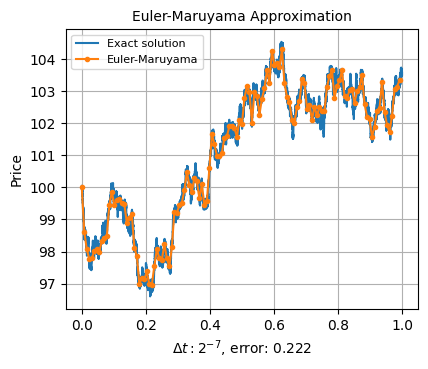

In [365]:
np.random.seed(random_seed)
mu = 0.03      # Drift
sigma = 0.05   # Diffusion
x0 = 100       # Initial price
N = 2**15      # Brownian increments
T = 1          # Time horizon
dt = T/N       # Time step size
W = np.sqrt(dt)*np.random.normal(0, 1, size=N) # Brownian

# Exact solution using Brownian motion with dt
Wt = dB.cumsum()
t = np.arange(0, T, dt)
Xt = np.zeros(len(t))
Xt[0] = x0
for i in range(1,len(t)):
    Xt[i] = x0 * np.exp((mu-0.5*sigma**2) * t_N[i-1] + sigma*Wt[i-1])
    
# Euler-Maruyama approximation
I = 2**7        # Euler increments
step = int(N/I) # Adjusted Brownian increments
Dt = step*dt    # Euler step size
t_e = np.arange(0, T, Dt)
Xe = np.zeros(I)
Xe[0] = x0
# Recalculate to adjusted Euler increments
Wt_e = np.array([np.sum(dB[k*step : (k+1)*step]) for k in range(I)])
for i in range(1, len(t_e)):
    Xe[i] = Xe[i-1] * (1 + mu*Dt + sigma * Wt_e[i-1])

# Calculate discrepancy
error = np.sqrt((Xt[-1] - Xe[-1])**2)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(221)
ax.plot(t, Xt, label="Exact solution")
ax.plot(t_e, Xe, marker=".", label="Euler-Maruyama")
ax.set_xlabel("$\Delta t: 2^{-7}$"+", error: {:.3f}".format(error))
ax.set_ylabel("Price")
ax.legend(prop={"size":8})
ax.set_title(r"Euler-Maruyama Approximation", size=10)
ax.grid(":")
plt.show()

<h2 style="text-align:center;">Order of Convergence</h2>

**Definition**. Let $X(t)$ be a process and $X_n$ denote the approximation of the value of $X(T)$ where $T = n\Delta t$. The **weak error** $e_{\Delta t}^{\text{weak}}$ with respect to some function $f$ is defined as:

\begin{align}
e_{\Delta t}^{\text{weak}} = \sup_{0 \lt t_n \le T} \bigg|\mathbb{E}\big[f(X_n)\big] - \mathbb{E}\big[f(X(t_n))\big] \bigg|
\end{align}

We say that $X_n$ converges weakly to $X(t)$ with order $\rho \gt 0$ if there exists a constant $C \gt 0$ independent of  $\Delta t$ such that:

\begin{align}
e_{\Delta t}^{\text{weak}} \le C \Delta t^{\rho}
\end{align}

for all sufficiently small $\Delta t$.

**Definition**. We define the **strong error** as $e_{\Delta t}^{\text{strong}}$ as:

\begin{align}
e_{\Delta t}^{\text{strong}} = \sup_{0 \le t_n \le T} \mathbb{E}\left[\left|X_n - X_{t_n}\right|\right]
\end{align}

We can say $X_n$ converges strongly to $X_t$ with the order $\rho \gt 0$ if there exists as constant $C \gt 0$ independent of $\Delta t$ such that

\begin{align}
e_{\Delta t}^{\text{strong}} \le C \Delta t^{\rho}
\end{align}

for all sufficiently small $\Delta t$.

**Euler-Maruyama method** converges strongly with the order $\rho=\frac{1}{2}$ or $O(\sqrt{\Delta t})$. This means the error decreases proportional to the square root of the step size, assuming the coefficients of the SDE satisfy Lipschitz continuity condition.

We test this assumption by taking the mean of errors from time steps $\Delta t=2^{-x}$ for values $5 \le x \le 15$. If (7.7) holds, taking the log of both sides

\begin{align}
log\left(e_{\Delta t}^{\text{strong}}\right) \le log(C) + \frac{1}{2} log(\Delta t)
\end{align}

In [59]:
def least_square_fit(X, Y):
    """ Utility function to fit the line y = mx + c """
    A = np.vstack([np.log(X), np.ones(len(X))]).T
    y = np.log(Y)
    slope_intercept = np.linalg.lstsq(A, y, rcond=None)[0]
    resid = np.linalg.norm(A.dot(slope_intercept) - y)**2
    return slope_intercept, resid

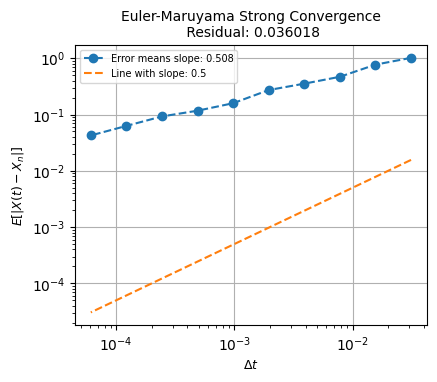

In [61]:
# Proof of Euler-Maruyama strong convergence order of 1/2
np.random.seed(random_seed)
mu = 2    # Drift
sigma = 1 # Diffusion
x0 = 1    # Starting price
N = 2**15 # Number of Brownian increments
T = 1     # Time horizon
dt = T/N  # Brownian step size
M = 100   # Number of MonteCarlo simulations
errors = np.zeros([M, 10]) # Matrix of errors

for m in range(M):  
    # Execute Monte-Carlo paths
    W = np.sqrt(dt) * np.random.normal(0,1,N)
    Wt = W.cumsum()
    for i in range(5,15):
        # Analytical solution 
        t = np.arange(0,T,dt)
        Xt = np.zeros(N)
        Xt[0] = x0
        for j in range(1, len(t)):
            Xt[j] = x0 * np.exp((mu-0.5*sigma**2)*t[j-1] + sigma*Wt[j-1])
            
        # Euler Approximation
        I = 2**i          # Euler Increments, <= Brownian increments to approximate
        step = round(N/I) # step size adjustment factor
        Dt = step*dt      # Euler adjusted time step
        te = np.arange(0, T, Dt)
        Wte = np.array([np.sum(W[k*step : (k+1)*step])for k in range(I)])
        Xe = np.zeros(I)
        Xe[0]=x0
        for l in range(1, len(te)):
            Xe[l] = Xe[l-1] * (1 + mu*Dt + sigma*Wte[l-1])
            
        # Errors
        errors[m, i-5] = np.abs(Xt[-1] - Xe[-1])

# Vector of Euler time step sizes used as X values and error means as Y values
Dts = np.array([2**x for x in range(-5, -15, -1)])
err_means = errors.mean(axis=0)
lst_sqr_fit, resid = least_square_fit(Dts, err_means)

rho, intercept = lst_sqr_fit
#assert math.isclose(m, 0.5, abs_tol=0.01)

fig =  plt.figure(figsize=(10,8))
ax = fig.add_subplot(221)
ax.loglog(Dts, err_means, marker="o", linestyle="dashed",
          label= "Error means slope: {:.3f}".format(rho))
ax.loglog(Dts, 0.5*Dts, linestyle="dashed", 
          label="Line with slope: 0.5")
ax.set_xlabel("$\Delta t$", size=9)
ax.set_ylabel("$E[|X(t)-X_n|]$", size=9)
ax.set_title("Euler-Maruyama Strong Convergence\n"
             + " Residual: {:.6f}".format(resid), size=10)
ax.legend(prop={"size":7})
ax.grid(":")
plt.show()

The experimental slope of the error means show in above figure is close identical to the sample line with $0.5$ slope. This proves numerically the strong error, $e_{\Delta t}^{\text{Strong}}$, convergence order $\rho=\frac{1}{2}$.

We can view weak convergence as the decay in the rate of the "error of the means" while strong convergence is the decay in the rate of the "mean of the errors". Strong convergence implies weak convergence, but the opposite is not necessarily true.
    
If a numerical scheme converges with the order $\rho$, then by decreasing the step size by a factor of $k$ reduces the error by a factor of $k^{\rho}$. For example, the order of $\rho=1$ means that decreasing the step size by a factor of $100$ also decreases the error by a factor of $100$. Meanwhile, an order of $\rho=\frac{1}{2}$ means that decreasing the step size by a factor of $100$ decreases the error by a factor of $10$.

We also assume that **Euler-Maruyama** approximation converges weakly to the exact solution $X(t)$ at time $T$ if for a class of functions the error in the expected value vanishes as $\Delta t$ approaches 0. As such, this numerical scheme focuses on statistical properties (e.g. mean and variance) of multiple simulation paths rather than a single solution.

\begin{align}
e_{\Delta t}^{\text{Weak}} &:= \big|E[X_n] -E[X(T)]\big| \Rightarrow \; 0 \;as\; \Delta t \Rightarrow 0
\end{align}

The order of convergence $\rho$ is generally equal to $1$ which means the error decreases linearly as $\Delta t$ goes to zero.

\begin{align}
e_{\Delta t}^{\text{Weak}} \le C\Delta t^{\rho}
\end{align}


To test this hypothesis, let us first find $E[X(t)]$, recall that:

\begin{align}
dX_t =  \mu X_tdt + \sigma X_tdB_t
\end{align}

Converting to integral form:

\begin{align}
X_t =  X_0 + \mu \int_0^t X_s ds + \sigma \int_0^t X_s dB_s
\end{align}


We take the expectation of both sides

\begin{align}
\mathbb{E}[X_t] &=  \mathbb{E}[X_0] + \mu \mathbb{E}\left[\int_0^t X_s ds\right] 
+ \sigma \mathbb{E}\left[\int_0^t X_sdB_s\right]\\
d\mathbb{E}[X_t] &= \mathbb{E}[X_0] + \mu \mathbb{E}[X_t]ds + 0
\end{align}

This implies

\begin{align}
d\mathbb{E}[X_t] = \mu\mathbb{E}[X_t]dt, \quad \mathbb{E}[X_0] = x_0
\end{align}

Which solves to a known solution

\begin{align}
d\mathbb{E}[X_t] = X_0e^{ut}
\end{align}

We run the numerical experiment over $M=10^6$ sample paths using Monte-Carlo simulation with values of $\Delta t = 2^{-x}$ such that $5 \lt x \lt 11$

\begin{align}
\big|\mathbb{E}[X_n] - \mathbb{E}[X(T)] \big|, \quad n\Delta t = T
\end{align}


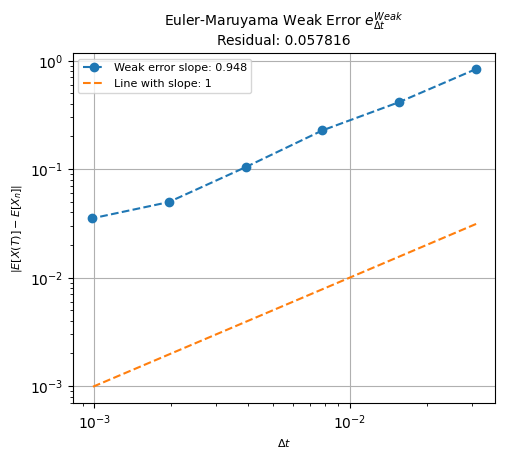

In [60]:
# Proof of Euler-Maruyama weak convergence order of 1
np.random.seed(random_seed)
mu = 2            # Drift
sigma = 1         # Diffusion
x0 = 1            # Initial value
N = 2**15         # Number of discrete Brownian increments
T = 1             # Time horizon
dt = T/N          # Step size
M = 10**6         # Monte-Carlo simulation paths
Xe = np.zeros(6)  # Price data array

for i in range(5, 11):
    I = 2**i  # Number of Euler increments
    step = round(N/I)
    Dt = step*dt
    temp = np.zeros((M, I))
    for m in range(M):
        Wt = np.sqrt(Dt) * np.random.normal(0, 1, I)
        temp[m, 0] = x0
        for t in range(1, I):
            temp[m, t] = temp[m, t-1] * (1 + mu*Dt + sigma*Wt[t-1]) 
    Xe[i-5] = np.mean(temp[:,-1])
    
weak_errors = abs(Xe - x0 * np.exp(mu*T))
weak_errors = weak_errors.T

Dts = np.array([2**x for x in range(-5, -11, -1)])
([slope, intercept], residual) = least_square_fit(Dts, weak_errors)

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(221)
ax.loglog(Dts, abs(weak_errors), marker="o",
          linestyle="dashed", label="Weak error slope: {:.3f}".format(slope))
ax.loglog(Dts, Dts, linestyle="dashed", label="Line with slope: 1")
ax.set_xlabel("$\Delta t$", size=8)
ax.set_ylabel("$|E[X(T)]-E[X_n]|$", size=8)   
ax.set_title("Euler-Maruyama Weak Error $e_{\Delta t}^{Weak}$ \n" 
            + "Residual: {:.6f}".format(residual), size=10)
ax.legend(prop={"size":8})
ax.grid(":")
plt.show()

The experimental slope of the error means closely matches the weak convergence order of $\rho=1$. The slope of the errors is visually identical to the sample line with slope equal to $1$.

<h2 style="text-align:left;">Reference</h2>

[[^](https://en.wikipedia.org/wiki/Euler%E2%80%93Maruyama_method)] Euler-Maruyama Method, Wikipedia